# NFW host: decoupled-ledger tidal evolution (Mode B)

A one-off experiment testing whether Du+24's Table IV calibration reproduces their eq. 19 tidal track when SatGen's stripping pipeline is rebuilt to decouple the bound-mass ledger from the profile structure:

- heating (`heat_profile`, Du+24 monotonic shell expansion) is the **sole** reshaper of the density profile — no hard cut, no rebuild from the bound mass;
- the King62 / Zentner+05 bound mass $m$ is a **decoupled scalar** ODE; it never reshapes the profile;
- the infall subhalo carries a Kazantzidis+06 exponential tail fixed at $r_{\rm vir}$ (decay scale $r_{\rm vir}$) as a finite-mass regularizer.

$r_{\rm max}$, $V_{\rm max}$ come from the heated profile; the bound fraction $x = m/m_0$ from the King62 ledger. The two are independent measurements — Du+24's calibration is what should make them jointly trace eq. 19. This decoupled design is inspired by Galacticus. Run by `scripts/run_truncation_experiments.py` (`evolve_galacticus`).

In [1]:
import numpy as np
import pickle

import matplotlib as mpl
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['font.size'] = 15
import matplotlib.pyplot as plt
%matplotlib inline

%load_ext autoreload
%autoreload 2
import config as cfg
import stripping_common as sc


def du24_nfw_track(x, mu_V=0.6175, eta_V=0.2895, mu_R=0.5529, eta_R=0.4675):
    """Du+24 eq. (19) tidal track, NFW subhalo on NFW host. Returns
    (R_max/R_max0, V_max/V_max0) parametric in x = m_bound/m_bound,0."""
    V = 2**mu_V * x**eta_V / (1.0 + x)**mu_V
    R = 2**mu_R * x**eta_R / (1.0 + x)**mu_R
    return R, V

>>> Normalizing primordial power spectrum P(k)=(k/k_0)^n_s ...
    such that sigma(R=8Mpc/h) =   0.8000.
>>> Tabulating sigma(M,z=0) ...
    From now on, sigma(M,z) is computed by interpolation.
>>> Tabulating z(W) and z(t_lkbk)...
>>> Preparing output redshifts for merger trees ...
    Number of output redshifts =  354, up to z = 20.06
>>> Tabulating Parkinson+08 J(u_res) ...
>>> Building interpolation grid for Green+19 M(<r|f_b,c)...
>>> Building interpolation grid for Green+19 sigma(r|f_b,c)...
>>> Building interpolation grid for Green+19 d2Phidr2(r|f_b,c)...
>>> Building interpolator for Jiang+15 orbit sampler...


In [2]:
cfg.Mres = 1e3  # match the resolution floor set in the driver workers

with open('truncation_experiments.pkl', 'rb') as fh:
    data = pickle.load(fh)
res = data['results']
M_tot_sub = data['M_tot_sub']
print(f"loaded {len(res)} runs, M_tot_sub = {M_tot_sub:.2e} Msun")

loaded 12 runs, M_tot_sub = 1.00e+09 Msun


## Tidal track — $V_{\rm max}$ vs $r_{\rm max}$

$V_{\rm max}/V_{\rm max,0}$ against $r_{\rm max}/r_{\rm max,0}$, both read from the heated profile. Du+24's eq. 19 track, evaluated parametrically in $x = m/m_0$, is overlaid as the target the run should land on.

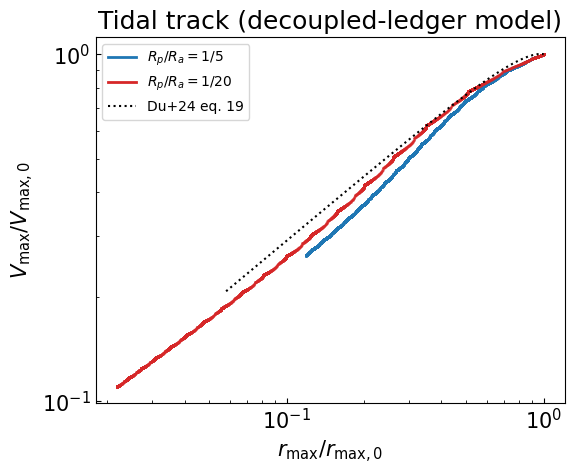

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
x_ref = np.logspace(-3, 0, 400)
R_du, V_du = du24_nfw_track(x_ref)

for orbit, color in (('1/5', 'C0'), ('1/20', 'C3')):
    r = res[f'{orbit} galacticus (1st+2nd)']
    mask = np.isfinite(r.vmax) & np.isfinite(r.rmax)
    ax.plot(r.rmax[mask] / r.rmax0, r.vmax[mask] / r.vmax0, '.', ms=2,
            alpha=0.5, color=color, label=f'$R_p/R_a={orbit}$')
ax.plot(R_du, V_du, 'k:', lw=1.5, label='Du+24 eq. 19')

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'$r_{\rm max}/r_{\rm max,0}$')
ax.set_ylabel(r'$V_{\rm max}/V_{\rm max,0}$')
ax.set_title('Tidal track (decoupled-ledger model)')
h, l = ax.get_legend_handles_labels()
ax.legend(handles=sc.markers_to_lines(h), labels=l, fontsize=10)
fig.tight_layout()
plt.show()

## Mass loss

Bound mass $m(t)$ against time, both orbits, with Du+24's Fig. 10 N-body history overlaid.

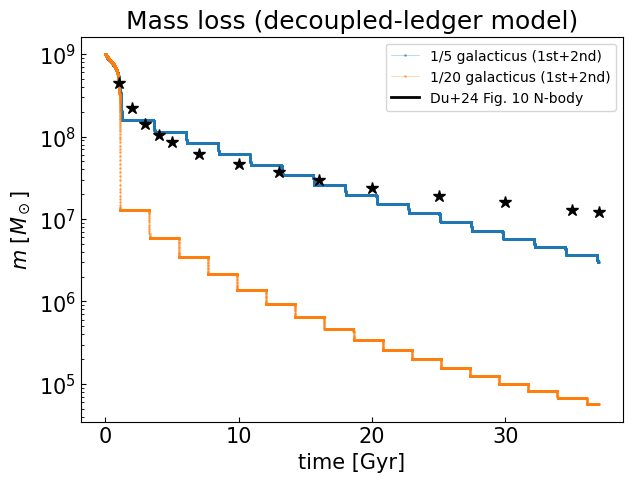

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
runs = [res['1/5 galacticus (1st+2nd)'], res['1/20 galacticus (1st+2nd)']]
sc.plot_mass_loss(runs, ax=ax, legend=False, title='Mass loss (decoupled-ledger model)')

# Du+24 Fig. 10 N-body bound mass (gamma=1, Rp/Ra=1/20), read by eye.
t_du = np.array([1., 2., 3., 4., 5., 7., 10., 13., 16., 20., 25., 30., 35., 37.])
x_du = np.array([0.45, 0.22, 0.14, 0.105, 0.085, 0.062, 0.046, 0.037,
                 0.030, 0.024, 0.019, 0.016, 0.013, 0.012])
ax.plot(t_du, x_du * M_tot_sub, 'k*', ms=9, label='Du+24 Fig. 10 N-body', zorder=5)

h, l = ax.get_legend_handles_labels()
ax.legend(handles=sc.markers_to_lines(h), labels=l, fontsize=10)
plt.show()

In [5]:
#---deepest / final bound fraction per run
def summary(tag):
    r = res[tag]
    m = r.m[np.isfinite(r.m)]
    t = r.t[np.isfinite(r.m)]
    fl = np.where(m <= cfg.Mres)[0]
    if len(fl):
        return f"disrupts at t = {t[fl[0]]:.2f} Gyr"
    return f"survives, final x = {m[-1] / M_tot_sub:.3e}, deepest x = {m.min() / M_tot_sub:.3e}"

for orbit in ('1/5', '1/20'):
    print(f"Rp/Ra = {orbit}:")
    for order in ('1st', '1st+2nd'):
        print(f"  galacticus {order:8s}: {summary(f'{orbit} galacticus ({order})')}")

Rp/Ra = 1/5:
  galacticus 1st     : survives, final x = 5.519e-02, deepest x = 5.519e-02
  galacticus 1st+2nd : survives, final x = 2.971e-03, deepest x = 2.971e-03
Rp/Ra = 1/20:
  galacticus 1st     : survives, final x = 4.043e-03, deepest x = 4.043e-03
  galacticus 1st+2nd : survives, final x = 5.693e-05, deepest x = 5.693e-05


## Profile snapshots

Heating alone reshapes the profile; the King62 ledger never truncates it. The Kazantzidis tail at $r_{\rm vir}$ stays as the outer envelope.

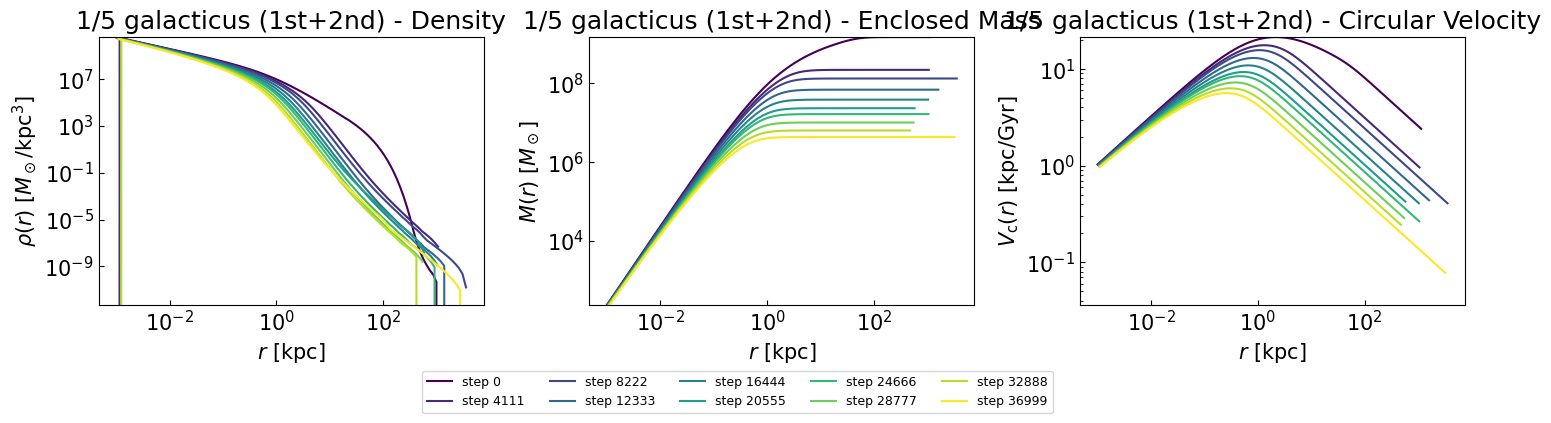

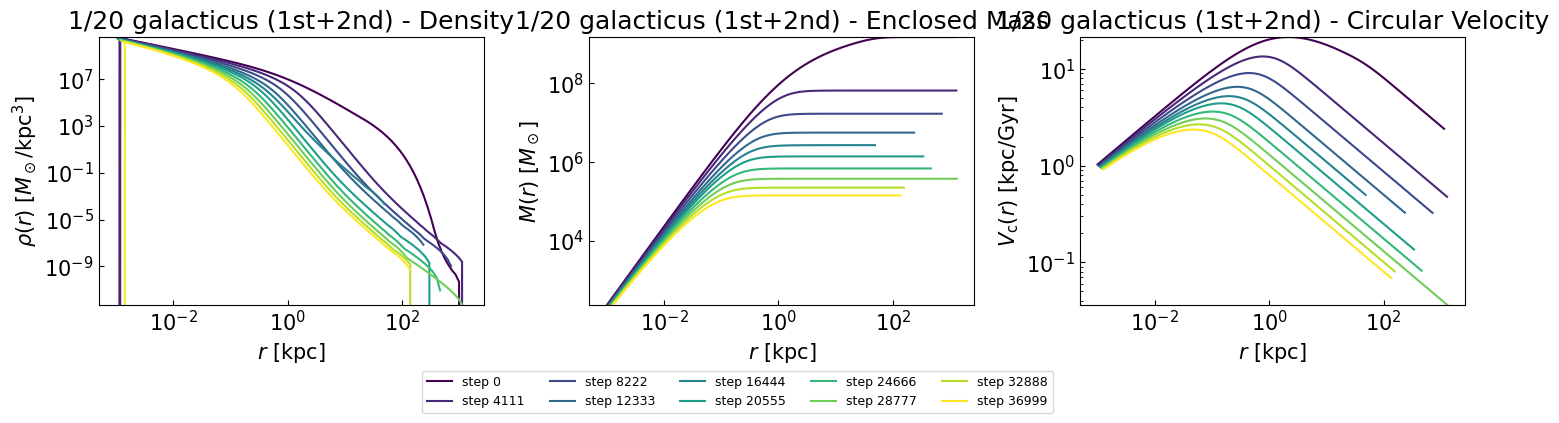

In [6]:
shared = sc.profile_ylims(res['1/5 galacticus (1st+2nd)'],
                          res['1/20 galacticus (1st+2nd)'])
for tag in ('1/5 galacticus (1st+2nd)', '1/20 galacticus (1st+2nd)'):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sc.plot_profile_snapshots(res[tag], axes=axes, title_prefix=tag + ' - ',
                              ylims=shared)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, fontsize=9, loc='lower center',
               bbox_to_anchor=(0.5, -0.08), ncol=5)
    plt.tight_layout()
    plt.show()